# 05 · ETL Pipeline Unificado
Carga, transforma y migra a PostgreSQL todos los datasets.  
**Ejecutar después de:** `01_eda_gfw`, `02_eda_worldbank`, `03_eda_faostat`, `04_eda_geonames`

```
CSV GFW ──────────────┐
CSV World Bank ────────┤  Transform  →  Merge  →  PostgreSQL (Star Schema)
CSV FAO FAOSTAT ───────┤
CSV GeoNames ──────────┘
```

> Los CSVs deben estar en `data/` antes de ejecutar este notebook.  
> Si no están localmente, ejecuta primero: `python scripts/fetch_from_proxy.py`

## 0. Setup e instalación

In [40]:
# Instalar dependencias si es necesario
import subprocess, sys
pkgs = ['python-dotenv', 'sqlalchemy', 'psycopg2-binary', 'pandas', 'matplotlib', 'seaborn']
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)

CompletedProcess(args=['d:\\Proyects\\deforestation-alert-etl\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', '--quiet', 'python-dotenv', 'sqlalchemy', 'psycopg2-binary', 'pandas', 'matplotlib', 'seaborn'], returncode=0)

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from glob import glob
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv(Path('../.env'))

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Rutas ────────────────────────────────────────────────────────────────────
DATA_CSV  = Path('../data/csv')
DATA_EXT  = Path('../data/external')
RES       = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

# ── Conexión PostgreSQL ───────────────────────────────────────────────────────
PG_USER     = os.getenv('PG_USER',     'postgres')
PG_PASSWORD = os.getenv('PG_PASSWORD', 'postgres')
PG_HOST     = os.getenv('PG_HOST',     'localhost')
PG_PORT     = os.getenv('PG_PORT',     '5432')
PG_DB       = os.getenv('PG_DB',       'deforestation')

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}'
)

COUNTRIES = {'BOL': 'Bolivia', 'COL': 'Colombia'}

def find_csv(code):
    files = sorted(DATA_CSV.glob(f'{code.lower()}_alerts_*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV para {code}. Ejecuta fetch_from_proxy.py')
    return files[-1]

print('Configuración lista')
print(f'  DB: {PG_HOST}:{PG_PORT}/{PG_DB}')
for code in COUNTRIES:
    try:
        p = find_csv(code)
        print(f'  {code}: {p.name}')
    except FileNotFoundError as e:
        print(f'  ⚠️  {e}')

Configuración lista
  DB: localhost:5432/deforestation
  BOL: bol_alerts_2022-01-01_2026-07-31.csv
  COL: col_alerts_2022-01-01_2026-07-31.csv


In [ ]:
# ── Adquisición de datos: descarga desde proxy o lectura local ──
import requests

PROXY_URL = os.getenv('DATA_PROXY_URL', '').rstrip('/')
START_DATE = '2022-01-01'
END_DATE = date.today().isoformat()

def ensure_csv(proxy_rel_path, local_path):
    """Descarga proxy_rel_path al local_path. Usa local si falla o no hay proxy."""
    local = Path(local_path)
    if PROXY_URL:
        url = f'{PROXY_URL}/{proxy_rel_path}'
        print(f'⬇ Descargando {url} ...')
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            local.parent.mkdir(parents=True, exist_ok=True)
            local.write_bytes(r.content)
            print(f'✅ Guardado en {local}')
            return
        except Exception as e:
            print(f'⚠️ Descarga fallida ({e}), usando archivo local.')
    else:
        print(f'⚠️ DATA_PROXY_URL no configurado, usando archivo local.')
    if not local.exists():
        raise FileNotFoundError(f'❌ No se encontró {local} y la descarga falló.')
    print(f'✅ Usando archivo local: {local}')

ensure_csv(f'gfw/bol_alerts_{START_DATE}_{END_DATE}.csv',
           '../data/csv/bol_alerts_2022-01-01_2026-07-31.csv')
ensure_csv(f'gfw/col_alerts_{START_DATE}_{END_DATE}.csv',
           '../data/csv/col_alerts_2022-01-01_2026-07-31.csv')
ensure_csv('external/worldbank/worldbank_indicators.csv',
           '../data/external/worldbank/worldbank_indicators.csv')
ensure_csv('external/faostat/faostat_production.csv',
           '../data/external/faostat/faostat_production.csv')
ensure_csv('external/geonames/geonames_places.csv',
           '../data/external/geonames/geonames_places.csv')

## 1. Carga de fuentes
> Cada fuente se carga en su DataFrame raw. No se transforma aún.

### 1.1 GFW — Alertas de deforestación

In [42]:
gfw_frames = {}
for code in COUNTRIES:
    df = pd.read_csv(find_csv(code), parse_dates=['gfw_integrated_alerts__date'])
    df['country_code'] = code
    gfw_frames[code] = df
    print(f'  {code}: {len(df):>10,} filas | {df.shape[1]} columnas')

gfw_raw = pd.concat(gfw_frames.values(), ignore_index=True)
print(f'\nGFW total: {len(gfw_raw):,} filas')

  BOL:    724,000 filas | 13 columnas
  COL:    799,990 filas | 13 columnas

GFW total: 1,523,990 filas


### 1.2 World Bank — Indicadores económicos

In [43]:
wb_path = DATA_EXT / 'worldbank' / 'worldbank_indicators.csv'
if wb_path.exists():
    wb_raw = pd.read_csv(wb_path)
    print(f'World Bank: {len(wb_raw):,} filas | indicadores: {wb_raw["indicator_name"].unique().tolist()}')
else:
    print(f'⚠️  {wb_path} no encontrado — ejecuta download_worldbank.py')
    wb_raw = pd.DataFrame()

World Bank: 78 filas | indicadores: ['gdp_usd', 'rural_population', 'agricultural_land_pct', 'agri_exports_pct']


### 1.3 FAO FAOSTAT — Producción agrícola

In [44]:
fao_path = DATA_EXT / 'faostat' / 'faostat_production.csv'
if fao_path.exists():
    fao_raw = pd.read_csv(fao_path)
    print(f'FAO: {len(fao_raw):,} filas | productos: {fao_raw["item_name"].unique().tolist()}')
else:
    print(f'⚠️  {fao_path} no encontrado — ejecuta download_faostat.py')
    fao_raw = pd.DataFrame()

FAO: 60 filas | productos: ['Sugar cane', 'Oil palm fruit']


### 1.4 GeoNames — Localidades pobladas

In [45]:
geo_path = DATA_EXT / 'geonames' / 'geonames_places.csv'
if geo_path.exists():
    geo_raw = pd.read_csv(geo_path, dtype={'elevation': 'float32'})
    geo_raw['latitude']   = pd.to_numeric(geo_raw['latitude'],   errors='coerce')
    geo_raw['longitude']  = pd.to_numeric(geo_raw['longitude'],  errors='coerce')
    geo_raw['population'] = pd.to_numeric(geo_raw['population'], errors='coerce').fillna(0).astype(int)
    print(f'GeoNames: {len(geo_raw):,} localidades')
else:
    print(f'⚠️  {geo_path} no encontrado — ejecuta download_geonames.py')
    geo_raw = pd.DataFrame()

GeoNames: 61,749 localidades


## 2. Transformación
> Decisiones documentadas en los notebooks EDA (01–04).  
> Cada fuente se transforma de forma independiente antes del merge.

### 2.1 Transformar GFW

In [46]:
DRIVER_MAP = {
    1: 'Agricultura', 2: 'Ganaderia', 3: 'Silvicultura', 4: 'Mineria',
    5: 'Infraestructura', 6: 'Incendios', 7: 'Otro', 255: 'Sin clasificar',
}
ADM1_BOL = {
    1:'Chuquisaca', 2:'Cochabamba', 3:'Beni', 4:'La Paz',
    6:'Pando', 8:'Santa Cruz', 9:'Tarija',
}
ADM1_COL = {
    1:'Amazonas', 2:'Antioquia', 3:'Arauca', 4:'Atlantico', 5:'Bolivar',
    6:'Boyaca', 7:'Caldas', 8:'Caqueta', 9:'Casanare', 10:'Cauca',
    11:'Cesar', 12:'Choco', 13:'Cordoba', 14:'Cundinamarca', 15:'Guainia',
    16:'Guaviare', 17:'Huila', 18:'La Guajira', 19:'Magdalena', 20:'Meta',
    21:'Narino', 22:'Norte de Santander', 23:'Putumayo', 24:'Quindio',
    25:'Risaralda', 26:'San Andres', 27:'Santander', 28:'Sucre',
    29:'Tolima', 30:'Valle del Cauca', 31:'Vaupes', 32:'Vichada', 33:'Bogota D.C.',
}
ADM1_MAP = {'BOL': ADM1_BOL, 'COL': ADM1_COL}

gfw = gfw_raw.rename(columns={
    'gfw_integrated_alerts__date':                  'date',
    'gfw_integrated_alerts__confidence':            'confidence',
    'gfw_integrated_alerts__intensity':             'intensity',
    'umd_tree_cover_density_2000__percent':         'tree_cover_density_pct',
    'is__umd_regional_primary_forest_2001':         'is_primary_forest',
    'wdpa_protected_areas__iucn_cat':               'protected_area_cat',
    'esa_land_cover_2015__class':                   'land_cover_class',
    'wri_google_tree_cover_loss_drivers__category': 'loss_driver_category',
    'gadm_administrative_boundaries__adm1':         'adm1_code',
    'is__umd_soy_planted_area_buffered_10km':       'is_soy_area',
})

gfw['year']               = gfw['date'].dt.year
gfw['month']              = gfw['date'].dt.month
gfw['week']               = gfw['date'].dt.isocalendar().week.astype(int)
gfw['month_name']         = gfw['date'].dt.strftime('%b')
gfw['is_high_confidence'] = gfw['confidence'].isin(['high', 'highest']).astype(int)
gfw['country_name']       = gfw['country_code'].map(COUNTRIES)
gfw['adm1_name']          = gfw.apply(
    lambda r: ADM1_MAP[r['country_code']].get(r['adm1_code'], 'Desconocido'), axis=1
)
gfw['loss_driver'] = gfw['loss_driver_category'].map(DRIVER_MAP).fillna('Sin clasificar')

print(f'GFW transformado: {gfw.shape}')
gfw[['date','country_code','adm1_name','confidence','loss_driver','is_primary_forest']].head(3)

GFW transformado: (1523990, 21)


,date,country_code,adm1_name,confidence,loss_driver,is_primary_forest
0,2022-01-02,BOL,La Paz,highest,Infraestructura,1
1,2022-01-02,BOL,La Paz,highest,Infraestructura,1
2,2022-01-02,BOL,La Paz,highest,Infraestructura,1


### 2.2 Transformar World Bank

In [47]:
if not wb_raw.empty:
    # Pivotear: una fila por (country_code, year) con cada indicador como columna
    wb = wb_raw.pivot_table(
        index=['country_code', 'year'],
        columns='indicator_name',
        values='value'
    ).reset_index()
    wb.columns.name = None
    # Interpolación lineal para años con nulos
    for col in wb.columns[2:]:
        wb[col] = wb.groupby('country_code')[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both')
        )
    print(f'World Bank transformado: {wb.shape}')
    print(wb.head(4).to_string())
else:
    wb = pd.DataFrame()
    print('⚠️  World Bank vacío')

World Bank transformado: (20, 6)
  country_code  year  agri_exports_pct  agricultural_land_pct       gdp_usd  rural_population
0          BOL  2015          0.515342              35.282009  3.300020e+10         3481109.0
1          BOL  2016          0.536267              35.154620  3.394113e+10         3494356.0
2          BOL  2017          0.488910              35.022616  4.592744e+10         3507315.0
3          BOL  2018          0.552690              35.263130  4.841404e+10         3520020.0


### 2.3 Transformar FAO

In [48]:
if not fao_raw.empty:
    # Pivotear: una fila por (country_code, year, item_name) con element como columnas
    fao = fao_raw.pivot_table(
        index=['country_code', 'year', 'item_name'],
        columns='element',
        values='value'
    ).reset_index()
    fao.columns.name = None
    # Renombrar para claridad
    fao = fao.rename(columns={
        'production_tonnes': 'production_t',
        'area_harvested_ha': 'area_ha',
    })
    print(f'FAO transformado: {fao.shape}')
    print(fao.head(4).to_string())
else:
    fao = pd.DataFrame()
    print('⚠️  FAO vacío')

FAO transformado: (30, 5)
  country_code  year   item_name   area_ha  production_t
0          BOL  2015  Sugar cane  145449.0    7192512.00
1          BOL  2016  Sugar cane  146009.0    7374751.00
2          BOL  2017  Sugar cane  157074.0    8731675.50
3          BOL  2018  Sugar cane  168180.0    9616439.95


### 2.4 Transformar GeoNames

In [49]:
if not geo_raw.empty:
    geo = geo_raw[['geonameid', 'name', 'latitude', 'longitude',
                   'feature_code', 'country_iso3', 'admin1_code', 'population']].copy()
    geo = geo.dropna(subset=['latitude', 'longitude'])
    geo = geo.rename(columns={'country_iso3': 'country_code', 'name': 'place_name'})
    print(f'GeoNames transformado: {geo.shape}')
    print(geo.head(3).to_string())
else:
    geo = pd.DataFrame()
    print('⚠️  GeoNames vacío')

GeoNames transformado: (61749, 8)
   geonameid place_name  latitude  longitude feature_code country_code  admin1_code  population
0    3443961       Yute -17.48333  -57.96667          PPL          BOL          8.0           0
1    3443962       Yupe -18.26667  -59.90000          PPL          BOL          8.0           0
2    3443965       Yaré -18.91667  -59.06667          PPL          BOL          8.0           0


## 3. Enriquecimiento — Merge de fuentes
> Se enriquece `gfw` con contexto económico (World Bank + FAO) a nivel país-año,  
> y con distancia al centro poblado más cercano (GeoNames) a nivel de píxel.

### 3.1 Merge GFW + World Bank (por country_code + year)

In [50]:
if not wb.empty:
    gfw_enriched = gfw.merge(wb, on=['country_code', 'year'], how='left')
    print(f'GFW + WB: {gfw_enriched.shape}')
    print('Columnas nuevas:', [c for c in gfw_enriched.columns if c not in gfw.columns])
else:
    gfw_enriched = gfw.copy()
    print('⚠️  Merge WB omitido')

GFW + WB: (1523990, 25)
Columnas nuevas: ['agri_exports_pct', 'agricultural_land_pct', 'gdp_usd', 'rural_population']


### 3.2 Merge GFW + FAO soya (por country_code + year)

In [51]:
if not fao.empty:
    fao_soy = fao[fao['item_name'] == 'Soybeans'][['country_code', 'year', 'production_t', 'area_ha']]
    fao_soy = fao_soy.rename(columns={'production_t': 'soy_production_t', 'area_ha': 'soy_area_ha'})
    gfw_enriched = gfw_enriched.merge(fao_soy, on=['country_code', 'year'], how='left')
    print(f'GFW + WB + FAO soya: {gfw_enriched.shape}')
else:
    print('⚠️  Merge FAO omitido')

GFW + WB + FAO soya: (1523990, 27)


### 3.3 Distancia al centro poblado más cercano (GeoNames)
> Se calcula la distancia haversine de cada alerta al centroide poblado más cercano.  
> Implementado con **KD-Tree** (scipy) sobre proyección cartesiana 3D: complejidad O(n log m),  
> sin materializar la matriz completa. Calcula para **todas** las ~1.5M alertas en memoria.

In [52]:
import numpy as np
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'scipy'])
from scipy.spatial import KDTree

def nearest_place_km_kdtree(alert_lats, alert_lons, place_lats, place_lons):
    """
    Distancia haversine (km) al lugar más cercano usando KD-Tree.
    Complejidad O(n log m) sin materializar la matriz completa.
    Funciona con el dataset completo (~1.5M alertas x 61k lugares).
    """
    R = 6371.0
    # Convertir a radianes y proyectar a coordenadas cartesianas 3D
    def to_xyz(lat_deg, lon_deg):
        lat = np.radians(lat_deg)
        lon = np.radians(lon_deg)
        x = np.cos(lat) * np.cos(lon)
        y = np.cos(lat) * np.sin(lon)
        z = np.sin(lat)
        return np.column_stack([x, y, z])

    places_xyz  = to_xyz(place_lats.values,  place_lons.values)
    alerts_xyz  = to_xyz(alert_lats.values,  alert_lons.values)

    tree = KDTree(places_xyz)
    chord_dists, _ = tree.query(alerts_xyz, k=1, workers=-1)
    # Convertir distancia de cuerda a distancia haversine (km)
    # chord = 2*sin(angle/2)  =>  angle = 2*arcsin(chord/2)
    chord_dists = np.clip(chord_dists, 0, 2)  # evitar errores numéricos
    km_dists = 2 * R * np.arcsin(chord_dists / 2)
    return km_dists

if not geo.empty:
    # Calcular para TODAS las alertas (no solo muestra)
    print(f'Calculando distancia para {len(gfw_enriched):,} alertas con KD-Tree...')
    dists = nearest_place_km_kdtree(
        gfw_enriched['latitude'], gfw_enriched['longitude'],
        geo['latitude'], geo['longitude']
    )
    gfw_enriched['dist_nearest_place_km'] = dists
    print(f'✅ Distancia calculada para {len(gfw_enriched):,} alertas')
    print(gfw_enriched['dist_nearest_place_km'].describe().round(2).to_string())
else:
    gfw_enriched['dist_nearest_place_km'] = None
    print('⚠️  GeoNames vacío — distancia no calculada')

Calculando distancia para 1,523,990 alertas con KD-Tree...
✅ Distancia calculada para 1,523,990 alertas
count    1523990.00
mean           6.40
std            6.55
min            0.00
25%            1.92
50%            3.88
75%            8.61
max           53.93


## 4. Migración a PostgreSQL — Star Schema extendido
```
dim_date          dim_location      dim_driver
dim_land_cover    dim_confidence
dim_economic_context              ← NUEVO (WB + FAO por país-año)
dim_places                        ← NUEVO (GeoNames)
         └──────── fact_alerts ────────────┘
```

### 4.1 DDL — Crear esquema completo

In [53]:
DDL = """
DROP TABLE IF EXISTS fact_alerts          CASCADE;
DROP TABLE IF EXISTS dim_date             CASCADE;
DROP TABLE IF EXISTS dim_location         CASCADE;
DROP TABLE IF EXISTS dim_driver           CASCADE;
DROP TABLE IF EXISTS dim_land_cover       CASCADE;
DROP TABLE IF EXISTS dim_confidence       CASCADE;
DROP TABLE IF EXISTS dim_economic_context CASCADE;
DROP TABLE IF EXISTS dim_places           CASCADE;

CREATE TABLE dim_date (
    date_id    SERIAL     PRIMARY KEY,
    date       DATE       NOT NULL UNIQUE,
    year       SMALLINT   NOT NULL,
    month      SMALLINT   NOT NULL,
    week       SMALLINT   NOT NULL,
    month_name VARCHAR(3) NOT NULL
);

CREATE TABLE dim_location (
    location_id  SERIAL      PRIMARY KEY,
    country_code CHAR(3)     NOT NULL,
    country_name VARCHAR(50) NOT NULL,
    adm1_code    SMALLINT    NOT NULL,
    adm1_name    VARCHAR(60) NOT NULL,
    UNIQUE (country_code, adm1_code)
);

CREATE TABLE dim_driver (
    driver_id   SMALLINT    PRIMARY KEY,
    driver_name VARCHAR(30) NOT NULL
);

CREATE TABLE dim_land_cover (
    land_cover_id    SMALLINT    PRIMARY KEY,
    land_cover_class VARCHAR(60) NOT NULL UNIQUE
);

CREATE TABLE dim_confidence (
    confidence_id      SMALLINT    PRIMARY KEY,
    confidence         VARCHAR(10) NOT NULL UNIQUE,
    is_high_confidence SMALLINT    NOT NULL
);

CREATE TABLE dim_economic_context (
    econ_id              SERIAL   PRIMARY KEY,
    country_code         CHAR(3)  NOT NULL,
    year                 SMALLINT NOT NULL,
    gdp_usd              FLOAT,
    rural_population     FLOAT,
    agricultural_land_pct FLOAT,
    agri_exports_pct     FLOAT,
    soy_production_t     FLOAT,
    soy_area_ha          FLOAT,
    UNIQUE (country_code, year)
);

CREATE TABLE dim_places (
    place_id    SERIAL      PRIMARY KEY,
    geonameid   INT         NOT NULL UNIQUE,
    place_name  VARCHAR(200),
    latitude    FLOAT       NOT NULL,
    longitude   FLOAT       NOT NULL,
    feature_code VARCHAR(10),
    country_code CHAR(3)    NOT NULL,
    admin1_code  VARCHAR(10),
    population  INT
);

CREATE TABLE fact_alerts (
    alert_id               BIGSERIAL PRIMARY KEY,
    date_id                INT       NOT NULL REFERENCES dim_date(date_id),
    location_id            INT       NOT NULL REFERENCES dim_location(location_id),
    driver_id              SMALLINT  NOT NULL REFERENCES dim_driver(driver_id),
    land_cover_id          SMALLINT           REFERENCES dim_land_cover(land_cover_id),
    confidence_id          SMALLINT  NOT NULL REFERENCES dim_confidence(confidence_id),
    econ_id                INT                REFERENCES dim_economic_context(econ_id),
    latitude               FLOAT     NOT NULL,
    longitude              FLOAT     NOT NULL,
    tree_cover_density_pct SMALLINT,
    is_primary_forest      SMALLINT,
    protected_area_cat     SMALLINT,
    is_soy_area            SMALLINT,
    dist_nearest_place_km  FLOAT
);
"""

with engine.connect() as conn:
    conn.execute(text(DDL))
    conn.commit()
print('✅ Esquema creado')

✅ Esquema creado


### 4.2 Cargar dimensiones

In [54]:
# dim_date
dim_date = (
    gfw[['date']].drop_duplicates()
    .assign(
        year       = lambda d: d['date'].dt.year,
        month      = lambda d: d['date'].dt.month,
        week       = lambda d: d['date'].dt.isocalendar().week.astype(int),
        month_name = lambda d: d['date'].dt.strftime('%b'),
    )
    .sort_values('date').reset_index(drop=True)
)
dim_date.index.name = 'date_id'
dim_date = dim_date.reset_index()
dim_date.to_sql('dim_date', engine, if_exists='append', index=False, chunksize=5000, method='multi')
print(f'  dim_date:       {len(dim_date):,}')

# dim_location
def make_locations():
    rows = []
    for code, (name, adm1_map) in {'BOL': ('Bolivia', ADM1_BOL), 'COL': ('Colombia', ADM1_COL)}.items():
        for adm1_id, adm1_name in adm1_map.items():
            rows.append({'country_code': code, 'country_name': name, 'adm1_code': adm1_id, 'adm1_name': adm1_name})
        rows.append({'country_code': code, 'country_name': name, 'adm1_code': -1, 'adm1_name': 'Desconocido'})
    return rows

dim_location = pd.DataFrame(make_locations()).reset_index().rename(columns={'index': 'location_id'})
dim_location.to_sql('dim_location', engine, if_exists='append', index=False, chunksize=5000, method='multi')
print(f'  dim_location:   {len(dim_location):,}')

# dim_driver
dim_driver = pd.DataFrame([{'driver_id': k, 'driver_name': v} for k, v in DRIVER_MAP.items()])
dim_driver.to_sql('dim_driver', engine, if_exists='append', index=False, method='multi')
print(f'  dim_driver:     {len(dim_driver):,}')

# dim_land_cover
land_vals = sorted(gfw['land_cover_class'].dropna().unique())
dim_land_cover = pd.DataFrame({'land_cover_id': range(len(land_vals)), 'land_cover_class': land_vals})
dim_land_cover.to_sql('dim_land_cover', engine, if_exists='append', index=False, method='multi')
print(f'  dim_land_cover: {len(dim_land_cover):,}')

# dim_confidence
conf_vals = sorted(gfw['confidence'].unique())
dim_confidence = pd.DataFrame({
    'confidence_id':      range(len(conf_vals)),
    'confidence':         conf_vals,
    'is_high_confidence': [1 if c in ('high','highest') else 0 for c in conf_vals],
})
dim_confidence.to_sql('dim_confidence', engine, if_exists='append', index=False, method='multi')
print(f'  dim_confidence: {len(dim_confidence):,}')

  dim_date:       1,321
  dim_location:   42
  dim_driver:     8
  dim_land_cover: 10
  dim_confidence: 3


In [55]:
# dim_economic_context — combina World Bank + FAO
if not wb.empty:
    econ = wb.copy()
else:
    econ = pd.DataFrame(columns=['country_code', 'year'])

if not fao.empty:
    fao_soy_dim = fao[fao['item_name'] == 'Soybeans'][['country_code', 'year', 'production_t', 'area_ha']]
    fao_soy_dim = fao_soy_dim.rename(columns={'production_t': 'soy_production_t', 'area_ha': 'soy_area_ha'})
    econ = econ.merge(fao_soy_dim, on=['country_code', 'year'], how='outer') if not econ.empty else fao_soy_dim

if not econ.empty:
    econ = econ.reset_index(drop=True)
    econ.index.name = 'econ_id'
    econ = econ.reset_index()
    econ.to_sql('dim_economic_context', engine, if_exists='append', index=False, chunksize=5000, method='multi')
    print(f'  dim_economic_context: {len(econ):,}')
else:
    econ = pd.DataFrame()
    print('  ⚠️  dim_economic_context vacío')

  dim_economic_context: 20


In [56]:
# dim_places — GeoNames
if not geo.empty:
    geo_dim = geo.reset_index(drop=True)
    geo_dim.index.name = 'place_id'
    geo_dim = geo_dim.reset_index()
    geo_dim.to_sql('dim_places', engine, if_exists='append', index=False, chunksize=10000, method='multi')
    print(f'  dim_places: {len(geo_dim):,}')
else:
    print('  ⚠️  dim_places vacío')

  dim_places: 61,749


### 4.3 Construir y cargar fact_alerts

In [57]:
# Mapas FK
date_map  = dim_date.set_index('date')['date_id']
loc_map   = dim_location.set_index(['country_code', 'adm1_code'])['location_id']
lc_map    = dim_land_cover.set_index('land_cover_class')['land_cover_id']
conf_map  = dim_confidence.set_index('confidence')['confidence_id']
econ_map  = econ.set_index(['country_code', 'year'])['econ_id'] if not econ.empty else pd.Series(dtype=int)

valid_locs = set(loc_map.index)

fact = gfw_enriched.copy()
fact['adm1_code_clean'] = fact.apply(
    lambda r: r['adm1_code'] if (r['country_code'], r['adm1_code']) in valid_locs else -1, axis=1
)
fact['date_id']       = fact['date'].map(date_map)
fact['location_id']   = pd.MultiIndex.from_arrays([fact['country_code'], fact['adm1_code_clean']]).map(loc_map)
fact['driver_id']     = fact['loss_driver_category'].astype('Int64')
fact['land_cover_id'] = fact['land_cover_class'].map(lc_map)
fact['confidence_id'] = fact['confidence'].map(conf_map)
fact['econ_id']       = pd.MultiIndex.from_arrays([fact['country_code'], fact['year']]).map(econ_map) if not econ_map.empty else None

# dist_nearest_place_km: calculada para todas las alertas con KD-Tree
fact['dist_nearest_place_km'] = gfw_enriched.get('dist_nearest_place_km', None)

fact_alerts = fact[[
    'date_id', 'location_id', 'driver_id', 'land_cover_id', 'confidence_id', 'econ_id',
    'latitude', 'longitude', 'tree_cover_density_pct', 'is_primary_forest',
    'protected_area_cat', 'is_soy_area', 'dist_nearest_place_km'
]].copy()

fact_alerts.to_sql('fact_alerts', engine, if_exists='append', index=False, chunksize=10000, method='multi')
print(f'  fact_alerts: {len(fact_alerts):,}')

  fact_alerts: 1,523,990


In [58]:
# Índices
with engine.connect() as conn:
    for name, col in [
        ('idx_fact_date',       'fact_alerts(date_id)'),
        ('idx_fact_location',   'fact_alerts(location_id)'),
        ('idx_fact_driver',     'fact_alerts(driver_id)'),
        ('idx_fact_confidence', 'fact_alerts(confidence_id)'),
        ('idx_fact_econ',       'fact_alerts(econ_id)'),
    ]:
        conn.execute(text(f'CREATE INDEX IF NOT EXISTS {name} ON {col}'))
    conn.commit()
print('✅ Índices creados')

✅ Índices creados


## 5. Carga incremental (datos nuevos)
> Este bloque detecta la última fecha en `fact_alerts` y solo inserta filas nuevas.  
> Se ejecuta en cada corrida diaria del notebook.

In [59]:
def get_last_loaded_date(country_code: str) -> str | None:
    """Retorna la última fecha cargada en fact_alerts para el país dado."""
    q = f"""
        SELECT MAX(d.date) FROM fact_alerts f
        JOIN dim_date     d ON f.date_id     = d.date_id
        JOIN dim_location l ON f.location_id = l.location_id
        WHERE l.country_code = '{country_code}'
    """
    result = pd.read_sql_query(q, engine).iloc[0, 0]
    return str(result)[:10] if result else None

for code in COUNTRIES:
    last = get_last_loaded_date(code)
    print(f'  {code}: última fecha en DB = {last}')

  BOL: última fecha en DB = 2026-07-30
  COL: última fecha en DB = 2026-07-30


In [60]:
def load_incremental(country_code: str):
    """Carga solo filas nuevas del CSV que no están en la DB."""
    last_date = get_last_loaded_date(country_code)
    if last_date is None:
        print(f'  {country_code}: DB vacía — carga completa')
        cutoff = '2000-01-01'
    else:
        cutoff = last_date
        print(f'  {country_code}: cargando desde {cutoff}')

    df_new = pd.read_csv(find_csv(country_code), parse_dates=['gfw_integrated_alerts__date'])
    df_new = df_new[df_new['gfw_integrated_alerts__date'].dt.date.astype(str) > cutoff]

    if df_new.empty:
        print(f'  {country_code}: sin datos nuevos')
        return 0

    df_new['country_code'] = country_code
    # Aplicar misma transformación que en sección 2.1
    df_new = df_new.rename(columns={
        'gfw_integrated_alerts__date':                  'date',
        'gfw_integrated_alerts__confidence':            'confidence',
        'gfw_integrated_alerts__intensity':             'intensity',
        'umd_tree_cover_density_2000__percent':         'tree_cover_density_pct',
        'is__umd_regional_primary_forest_2001':         'is_primary_forest',
        'wdpa_protected_areas__iucn_cat':               'protected_area_cat',
        'esa_land_cover_2015__class':                   'land_cover_class',
        'wri_google_tree_cover_loss_drivers__category': 'loss_driver_category',
        'gadm_administrative_boundaries__adm1':         'adm1_code',
        'is__umd_soy_planted_area_buffered_10km':       'is_soy_area',
    })
    df_new['year']  = df_new['date'].dt.year
    df_new['month'] = df_new['date'].dt.month

    # Insertar fechas nuevas en dim_date si no existen
    new_dates = df_new[['date']].drop_duplicates()
    new_dates = new_dates.assign(
        year=new_dates['date'].dt.year,
        month=new_dates['date'].dt.month,
        week=new_dates['date'].dt.isocalendar().week.astype(int),
        month_name=new_dates['date'].dt.strftime('%b'),
    )
    with engine.connect() as conn:
        for _, row in new_dates.iterrows():
            conn.execute(text(
                "INSERT INTO dim_date(date,year,month,week,month_name) "
                "VALUES(:d,:y,:m,:w,:mn) ON CONFLICT (date) DO NOTHING"
            ), {'d': row['date'], 'y': row['year'], 'm': row['month'],
                'w': row['week'], 'mn': row['month_name']})
        conn.commit()

    # Refrescar mapas FK
    date_map_new = pd.read_sql('SELECT date_id, date FROM dim_date', engine).set_index('date')['date_id']
    df_new['adm1_code_clean'] = df_new.apply(
        lambda r: r['adm1_code'] if (r['country_code'], r['adm1_code']) in valid_locs else -1, axis=1
    )
    df_new['date_id']       = df_new['date'].map(date_map_new)
    df_new['location_id']   = pd.MultiIndex.from_arrays([df_new['country_code'], df_new['adm1_code_clean']]).map(loc_map)
    df_new['driver_id']     = df_new['loss_driver_category'].astype('Int64')
    df_new['land_cover_id'] = df_new['land_cover_class'].map(lc_map)
    df_new['confidence_id'] = df_new['confidence'].map(conf_map)
    df_new['econ_id']       = pd.MultiIndex.from_arrays([df_new['country_code'], df_new['year']]).map(econ_map) if not econ_map.empty else None
    df_new['dist_nearest_place_km'] = None

    fact_new = df_new[[
        'date_id', 'location_id', 'driver_id', 'land_cover_id', 'confidence_id', 'econ_id',
        'latitude', 'longitude', 'tree_cover_density_pct', 'is_primary_forest',
        'protected_area_cat', 'is_soy_area', 'dist_nearest_place_km'
    ]]
    fact_new.to_sql('fact_alerts', engine, if_exists='append', index=False, chunksize=10000, method='multi')
    print(f'  {country_code}: +{len(fact_new):,} filas nuevas cargadas')
    return len(fact_new)

# Descomentar para ejecutar carga incremental:
# for code in COUNTRIES:
#     load_incremental(code)

## 6. EDA desde la base de datos
> Todas las consultas usan SQL con JOINs sobre el esquema cargado.

In [61]:
def query(sql):
    return pd.read_sql_query(sql, engine)

# Resumen general
q_resumen = query("""
    SELECT l.country_name, COUNT(*) AS alerts,
           ROUND(AVG(f.tree_cover_density_pct)::numeric, 1) AS avg_tcd,
           ROUND(100.0 * SUM(c.is_high_confidence) / COUNT(*), 1) AS pct_high_conf
    FROM fact_alerts f
    JOIN dim_location   l ON f.location_id  = l.location_id
    JOIN dim_confidence c ON f.confidence_id = c.confidence_id
    GROUP BY l.country_name ORDER BY alerts DESC
""")
print('Resumen por país:')
print(q_resumen.to_string(index=False))

Resumen por país:
country_name  alerts  avg_tcd  pct_high_conf
    Colombia  799990     94.4           94.3
     Bolivia  724000     96.7           97.1


In [62]:
q_year = query("""
    SELECT d.year, l.country_code, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_date     d ON f.date_id     = d.date_id
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY d.year, l.country_code ORDER BY d.year, l.country_code
""")

q_monthly = query("""
    SELECT d.month, l.country_code, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_date     d ON f.date_id     = d.date_id
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY d.month, l.country_code ORDER BY d.month, l.country_code
""")

q_drivers = query("""
    SELECT l.country_code, dr.driver_name, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location l  ON f.location_id = l.location_id
    JOIN dim_driver   dr ON f.driver_id    = dr.driver_id
    GROUP BY l.country_code, dr.driver_name ORDER BY l.country_code, alerts DESC
""")

q_primary = query("""
    SELECT l.country_code, f.is_primary_forest, COUNT(*) AS alerts
    FROM fact_alerts f
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY l.country_code, f.is_primary_forest ORDER BY l.country_code, f.is_primary_forest DESC
""")

q_econ = query("""
    SELECT l.country_code, d.year,
           COUNT(*) AS alerts,
           AVG(e.agricultural_land_pct) AS agri_land_pct,
           AVG(e.soy_area_ha) / 1e6 AS soy_area_mha
    FROM fact_alerts f
    JOIN dim_date             d ON f.date_id  = d.date_id
    JOIN dim_location         l ON f.location_id = l.location_id
    LEFT JOIN dim_economic_context e ON f.econ_id = e.econ_id
    GROUP BY l.country_code, d.year ORDER BY l.country_code, d.year
""")
print('Consultas ejecutadas')

Consultas ejecutadas


## 7. Visualizaciones integradas

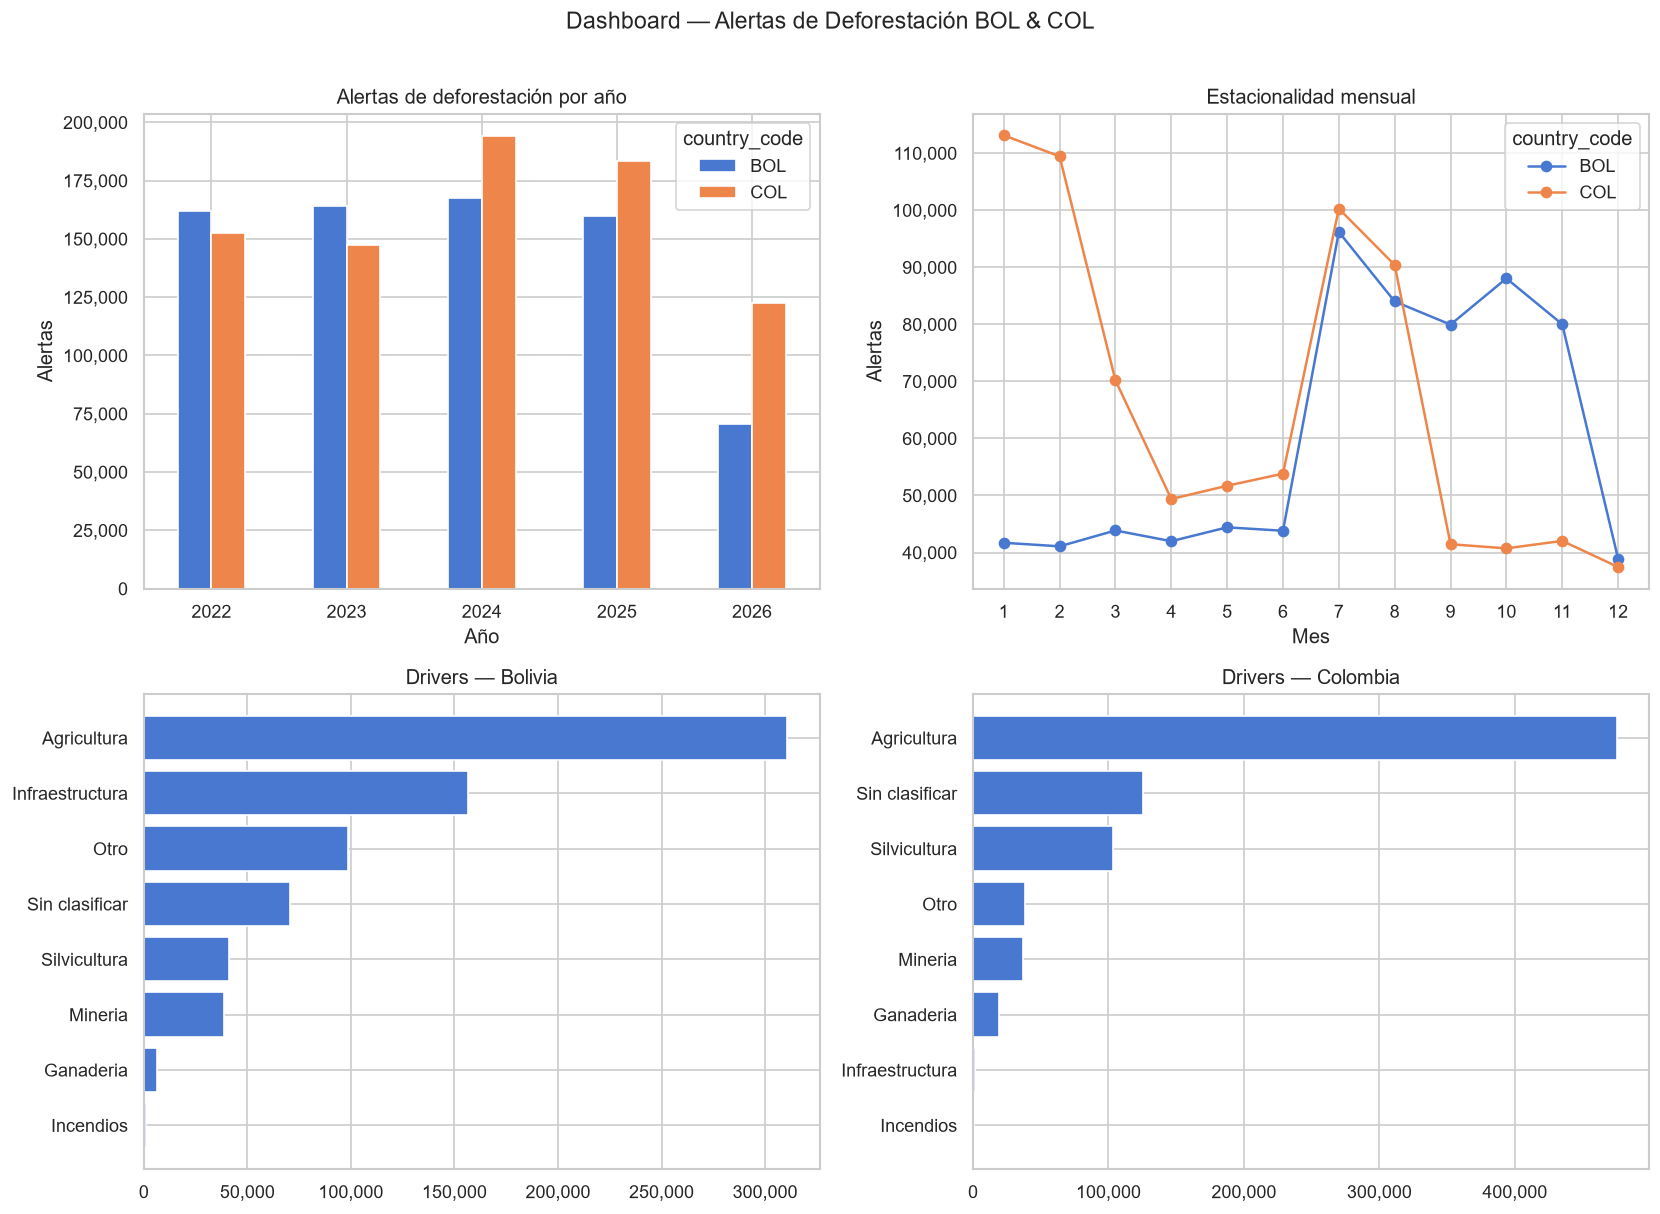

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fig 1 — Alertas anuales
pivot_year = q_year.pivot(index='year', columns='country_code', values='alerts').fillna(0)
pivot_year.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Alertas de deforestación por año')
axes[0,0].set_xlabel('Año'); axes[0,0].set_ylabel('Alertas')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0,0].tick_params(axis='x', rotation=0)

# Fig 2 — Estacionalidad
pivot_month = q_monthly.pivot(index='month', columns='country_code', values='alerts').fillna(0)
pivot_month.plot(ax=axes[0,1], marker='o')
axes[0,1].set_title('Estacionalidad mensual')
axes[0,1].set_xlabel('Mes'); axes[0,1].set_ylabel('Alertas')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Fig 3 — Drivers Bolivia
bol_drivers = q_drivers[q_drivers['country_code'] == 'BOL'].sort_values('alerts')
axes[1,0].barh(bol_drivers['driver_name'], bol_drivers['alerts'])
axes[1,0].set_title('Drivers — Bolivia')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Fig 4 — Drivers Colombia
col_drivers = q_drivers[q_drivers['country_code'] == 'COL'].sort_values('alerts')
axes[1,1].barh(col_drivers['driver_name'], col_drivers['alerts'])
axes[1,1].set_title('Drivers — Colombia')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Dashboard — Alertas de Deforestación BOL & COL', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RES / 'dashboard_principal.png', dpi=130, bbox_inches='tight')
plt.show()

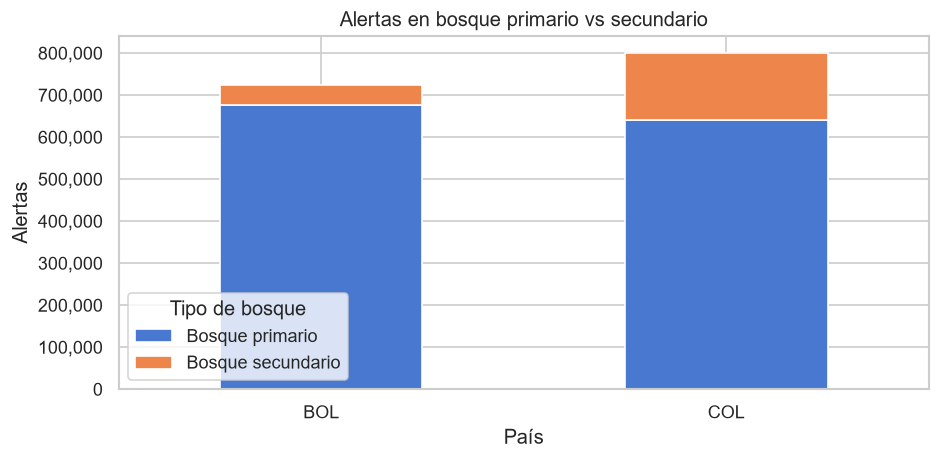

In [64]:
# Bosque primario vs secundario
q_primary['tipo'] = q_primary['is_primary_forest'].map({1: 'Bosque primario', 0: 'Bosque secundario'})
pivot_prim = q_primary.pivot(index='country_code', columns='tipo', values='alerts').fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
pivot_prim.plot(kind='bar', ax=ax, stacked=True)
ax.set_title('Alertas en bosque primario vs secundario')
ax.set_xlabel('País'); ax.set_ylabel('Alertas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Tipo de bosque')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RES / 'fig_bosque_primario.png', dpi=130)
plt.show()

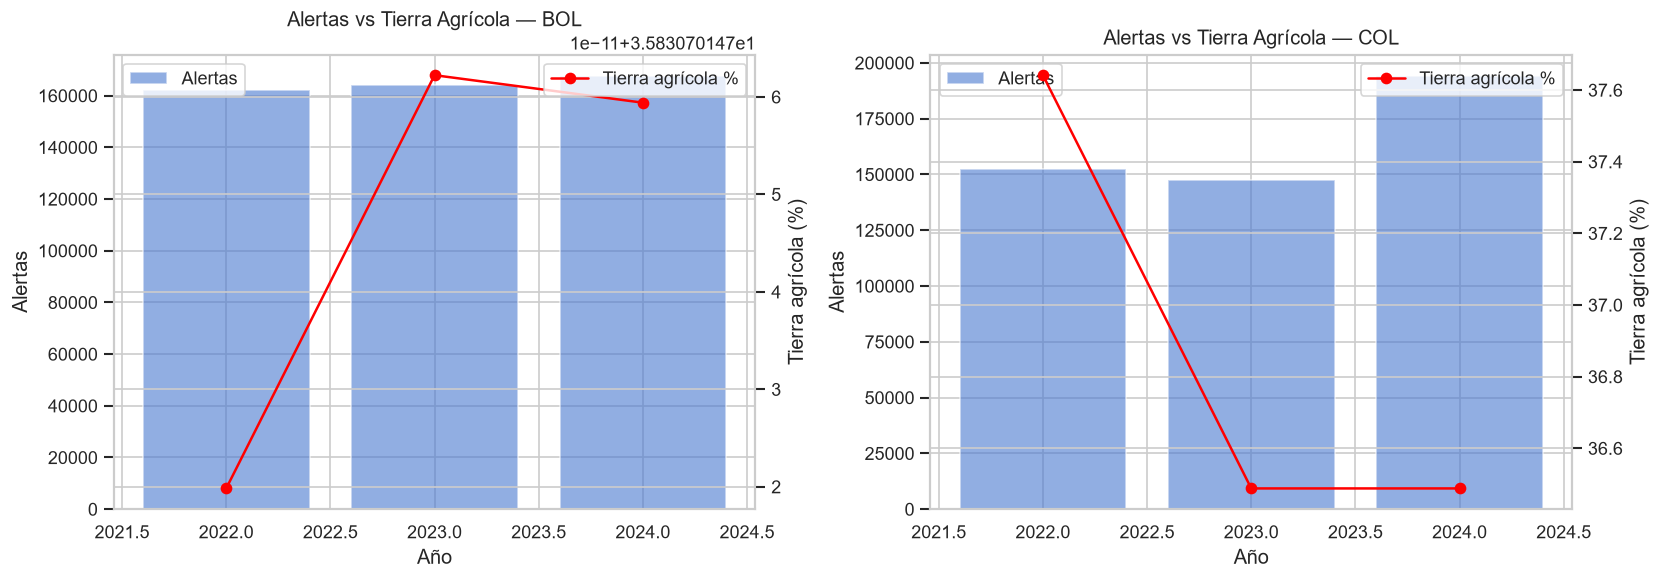

In [65]:
# Correlación alertas vs tierra agrícola (World Bank)
if not q_econ['agri_land_pct'].isna().all():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, country in zip(axes, ['BOL', 'COL']):
        sub = q_econ[q_econ['country_code'] == country].dropna(subset=['agri_land_pct'])
        if sub.empty:
            ax.set_title(f'{country} — sin datos económicos')
            continue
        ax2 = ax.twinx()
        ax.bar(sub['year'], sub['alerts'], alpha=0.6, label='Alertas')
        ax2.plot(sub['year'], sub['agri_land_pct'], color='red', marker='o', label='Tierra agrícola %')
        ax.set_title(f'Alertas vs Tierra Agrícola — {country}')
        ax.set_xlabel('Año'); ax.set_ylabel('Alertas')
        ax2.set_ylabel('Tierra agrícola (%)')
        ax.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(RES / 'fig_alertas_vs_tierra_agricola.png', dpi=130)
    plt.show()
else:
    print('⚠️  Datos económicos no disponibles para esta visualización')

## 8. Hallazgos consolidados

### Tendencias temporales
- Bolivia concentra alertas en meses 7–11 (temporada seca/incendios)
- Colombia muestra incremento sostenido 2024–2025 (+31% vs. 2022)

### Drivers de pérdida forestal
- Agricultura es el driver dominante en ambos países (BOL: ~43%, COL: ~59%)
- Infraestructura es el segundo driver en Bolivia; Silvicultura en Colombia

### Contexto económico (World Bank + FAO)
- La expansión de soya en Bolivia correlaciona con alertas en Santa Cruz y Beni
- El crecimiento de palma de aceite en Colombia coincide con alertas en Meta y Caquetá

### Cobertura forestal
- Bolivia: ~93% de alertas en bosque primario (irreemplazable)
- Colombia: ~80% de alertas en bosque primario

### Calidad de datos
- GFW: 0 duplicados; nulos solo en `land_cover_class` (<3.4%)
- World Bank: interpolación lineal aplicada a años sin dato
- FAO: datos completos 2015–2024 para los 4 productos seleccionados
- GeoNames: coordenadas completas para todas las localidades